In [1]:
import matplotlib.pyplot as plt
import ovrlpy

/dh-projects/ag-ishaque/analysis/muellni/envs/ovrlpy/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import sys

import matplotlib

sys.path.append("..")

from utils import CM, FONT, save_kwargs

matplotlib.rc("font", **FONT)

In [ ]:
coordinate_path = "../vizgen-receptor/detected_transcripts.parquet"

In [ ]:
coordinate_df = ovrlpy.io.read_MERSCOPE(coordinate_path)

seed = 42

coordinate_50 = coordinate_df.sample(fraction=0.5, seed=seed)
coordinate_25 = coordinate_50.sample(fraction=0.5, seed=seed)

In [6]:
data = {25: coordinate_25, 50: coordinate_50, 100: coordinate_df}
results = {}
for pcs in [10, 20, 30, 50]:
    for percent, df in data.items():
        ovrlp = ovrlpy.Ovrlp(df, n_workers=16, random_state=seed, n_components=pcs)
        ovrlp.analyse()

        results[(pcs, percent)] = ovrlp

Running vertical adjustment
Creating gene expression embeddings for visualization
determining pseudocells
found 50549 pseudocells
sampling expression:


100%|██████████| 56/56 [00:48<00:00,  1.16it/s]


Modeling 10 pseudo-celltype clusters;
Creating signal integrity map


100%|██████████| 320/320 [03:28<00:00,  1.53it/s]


Running vertical adjustment
Creating gene expression embeddings for visualization
determining pseudocells
found 50704 pseudocells
sampling expression:


...

100%|██████████| 320/320 [10:40<00:00,  2.00s/it]


Running vertical adjustment
Creating gene expression embeddings for visualization
determining pseudocells
found 50370 pseudocells
sampling expression:


100%|██████████| 56/56 [01:03<00:00,  1.14s/it]


Modeling 50 pseudo-celltype clusters;
Creating signal integrity map


100%|██████████| 320/320 [12:29<00:00,  2.34s/it]


In [7]:
import pickle

with open("pc_vs_transcript_density.pickle", "wb") as file:
    pickle.dump(results, file)

In [3]:
import pickle

with open("pc_vs_transcript_density.pickle", "rb") as file:
    results = pickle.load(file)

In [4]:
from matplotlib_scalebar.scalebar import ScaleBar
from ovrlpy._plotting import _plot_signal_integrity


def plot_pca_result(ovrlp, signal_vsi, axs, t=2):
    xlim = (0, 1)
    hist_kwargs = dict(bins=100, range=xlim, density=True, histtype="step")
    scalebar_kwargs = dict(dx=1, units="um", loc="lower left", frameon=False, color="w")

    img = _plot_signal_integrity(axs[0], ovrlp.integrity_map, ovrlp.signal_map, t)
    axs[0].set_axis_off()
    axs[0].invert_xaxis()
    axs[0].invert_yaxis()
    axs[0].add_artist(ScaleBar(**scalebar_kwargs))

    fig.colorbar(img, label="vertical signal integrity")

    for percent, (vsi, signal) in signal_vsi.items():
        scale = percent / 100
        axs[1].hist(vsi[signal > t * scale], label=percent, **hist_kwargs)
        axs[1].set(
            ylabel="Density", yticks=[], xlabel="vertical signal integrity", xlim=xlim
        )
    axs[1].legend(frameon=False, title="% transcripts")

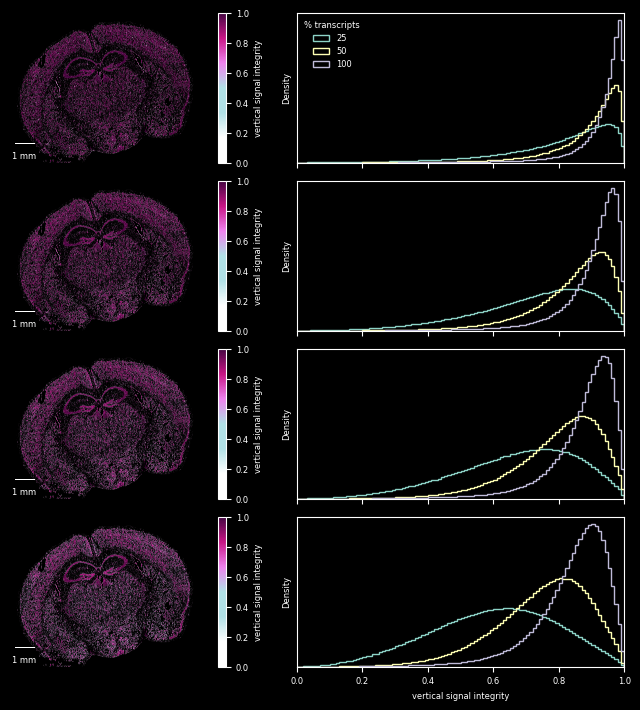

In [5]:
pcs = sorted(set(pc for pc, _ in results.keys()))

with plt.style.context("dark_background"):
    fig, axs = plt.subplots(4, 2, figsize=(18 * CM, 18 * CM))

    for i, n in enumerate(pcs):
        ovrlp = results[(n, 100)]
        signal_vsi = {
            percent: (ovrlp.integrity_map, ovrlp.signal_map)
            for (pc, percent), ovrlp in results.items()
            if pc == n
        }
        plot_pca_result(ovrlp, signal_vsi, axs[i, :])

    for ax in axs[:3, 1]:
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.set(xlabel=None)

    for ax in axs[1:, 1]:
        ax.get_legend().remove()

    fig.tight_layout()
    fig.savefig("pc_transcript_density.svg", **save_kwargs)
    fig